<a href="https://colab.research.google.com/github/ayatayoub20/Time-Series-Analysis/blob/main/Resampling_Datetime_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vT_jChgNsQbHbg4TGepzIqk8XC9DTIKmyyxb1upo5cfZCgbfIUQc2ZC0YMzuU5uApP140Ob49KBjdqh/pub?gid=1198589591&single=true&output=csv"

df = pd.read_csv(url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       14938 non-null  float64
 2   sunshine          14957 non-null  float64
 3   global_radiation  14939 non-null  float64
 4   max_temp          14951 non-null  float64
 5   mean_temp         14922 non-null  float64
 6   min_temp          14955 non-null  float64
 7   precipitation     14951 non-null  float64
 8   pressure          14953 non-null  float64
 9   snow_depth        13589 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [16]:
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [17]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [18]:
df = df.set_index('date')

In [19]:
df = df.loc['2000':]

In [20]:
df = df[['precipitation',
         'mean_temp',
         'min_temp',
         'max_temp',
         'snow_depth']]

In [21]:
df.isna().sum()

,0
precipitation,390
mean_temp,419
min_temp,386
max_temp,390
snow_depth,1752


In [22]:
df['precipitation'] = df['precipitation'].fillna(0)

In [23]:
df['snow_depth'] = df['snow_depth'].fillna(0)

In [24]:
df['mean_temp'] = df['mean_temp'].interpolate()
df['min_temp'] = df['min_temp'].interpolate()
df['max_temp'] = df['max_temp'].interpolate()

In [25]:
df.isna().sum()

,0
precipitation,0
mean_temp,0
min_temp,0
max_temp,0
snow_depth,0


#Q1 - What month had the most precipitation between 2000 through 2010?

In [26]:
precip_monthly = df['precipitation'].loc['2000':'2010']
precip_monthly = precip_monthly.resample('MS').sum()

In [27]:
max_date = precip_monthly.idxmax()
max_value = precip_monthly.max()

print(max_date)
print(max_value)

2009-11-01 00:00:00
138.4


In [37]:
print(precip_monthly.index.min())
print(precip_monthly.index.max())

2000-01-01 00:00:00
2010-12-01 00:00:00


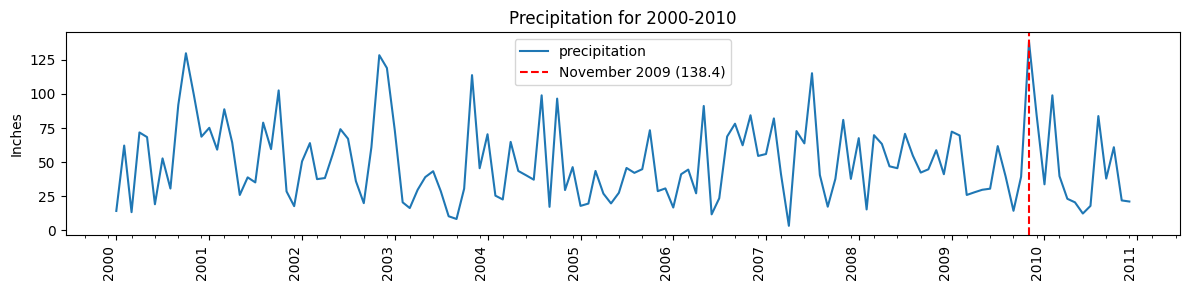

In [39]:
fig, ax = plt.subplots(figsize=(12,3))

ax.plot(precip_monthly.index, precip_monthly.values, label='precipitation')

ax.set_title("Precipitation for 2000-2010")
ax.set_ylabel("Inches")

ax.axvline(
    max_date,
    color='red',
    linestyle='--',
    label=f"{max_date.strftime('%B %Y')} ({max_value:.1f})"
)

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

fig.autofmt_xdate(rotation=90)

ax.legend()
plt.tight_layout()
plt.show()

The monthly precipitation data from 2000 to 2010 shows that the highest total precipitation occurred in November 2009, reaching 138.4 inches. The red dashed line highlights this month, indicating the peak precipitation level during the selected period.


#Q2 - Which year between 2000-2020 had the coolest average temperature?

In [40]:
yearly_temp = df['mean_temp'].loc['2000':'2020']

yearly_temp = yearly_temp.resample('YS').mean()

min_date = yearly_temp.idxmin()

min_value = yearly_temp.min()

print(min_date)
print(min_value)

2010-01-01 00:00:00
10.657397260273973


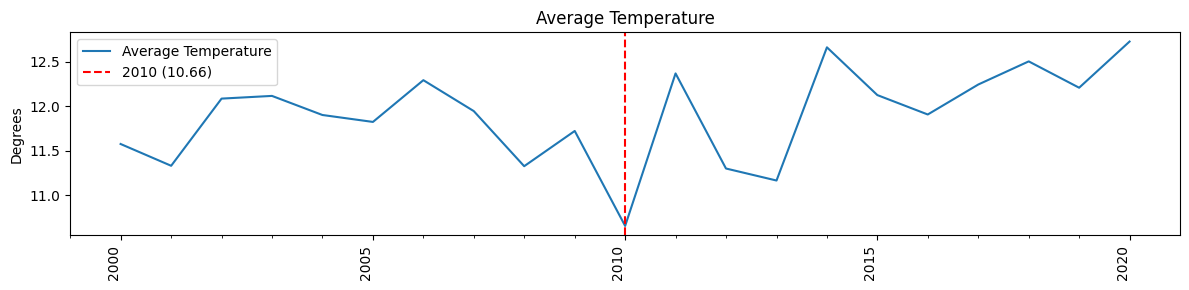

In [41]:
fig, ax = plt.subplots(figsize=(12,3))

ax.plot(yearly_temp.index, yearly_temp.values,
        label='Average Temperature')

ax.set_title("Average Temperature")
ax.set_ylabel("Degrees")

ax.axvline(
    min_date,
    color='red',
    linestyle='--',
    label=f"{min_date.strftime('%Y')} ({min_value:.2f})"
)

ax.xaxis.set_major_locator(
    mdates.YearLocator(5)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

ax.xaxis.set_minor_locator(
    mdates.YearLocator(1)
)

fig.autofmt_xdate(rotation=90)

ax.legend()

plt.tight_layout()
plt.show()

The coolest average temperature between 2000 and 2020 occurred in 2010, with an average mean temperature of approximately 10.66°C. The red dashed line highlights the year with the lowest average temperature during the selected period.
